## 8.3 学习率衰减策略 - 指数间隔学习率衰减

#### 1. 为什么需要指数学习率衰减
在前面我们已经学习了两种学习率衰减方法：
```
方法	                            特点
等间隔学习率衰减（StepLR）	        每隔固定 epoch 降一次
指定间隔学习率衰减（MultiStepLR） 	在指定 epoch 降一次
```
这两种方法都有一个共同特点：

`学习率是阶梯式下降`

例如：

`0.01 → 0.001 → 0.0001`

下降是 突然发生的。

但是在很多情况下，我们希望：

`学习率能够平滑下降`

也就是说：

`每个 epoch 都稍微降低一点学习率`

这样训练过程会更加稳定。

因此提出：

`指数学习率衰减（Exponential Decay）`

#### 2. 什么是指数学习率衰减
指数学习率衰减的核心思想是：

`学习率随着训练轮数按指数规律逐渐减小。`

也就是说：
* 每个 epoch
* 学习率都会乘以一个衰减系数

例如：

初始学习率：

`η₀ = 0.01`

衰减系数：

`γ = 0.95`

那么学习率变化如下：
```
Epoch	学习率
0	0.01
1	0.0095
2	0.009025
3	0.00857
4	0.00814
```
可以看到：
* 学习率是连续下降的
* 而不是阶梯下降。

#### 3. 指数学习率衰减的数学公式
指数学习率衰减的公式为：

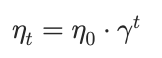

其中：

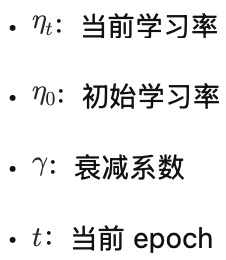

**衰减系数**

表示：

`每一轮学习率保留多少比例`

例如：
```
γ	    含义
0.99	每轮降低1%
0.95	每轮降低5%
0.9     每轮降低10%
```

#### 4. 示例计算
假设：
```
η₀ = 0.01
γ = 0.95
```
学习率变化：
```
Epoch	计算	学习率
0	0.01 × 0.95⁰	0.01
1	0.01 × 0.95¹	0.0095
2	0.01 × 0.95²	0.009025
3	0.01 × 0.95³	0.00857
4	0.01 × 0.95⁴	0.00814
```
可以看到：
* 学习率逐渐平滑减小

**指数学习率衰减的图像直观理解**

如果画出学习率变化曲线，大致是：
```
0.01 |\
     | \
     |  \
     |   \
     |    \
     |     \
     +------- epoch
```
可以看到：
* 学习率下降是连续曲线
* 而不是台阶式


#### 5. 与前两种方法的区别
```
方法	下降方式
StepLR	固定间隔阶梯下降
MultiStepLR	指定 epoch 阶梯下降
ExponentialLR	连续指数下降
```
总结：
* StepLR       → 固定间隔
* MultiStepLR  → 指定间隔
* Exponential  → 每一步都下降


#### 6. 指数学习率衰减的优点
**1️⃣ 学习率变化平滑**

相比阶梯下降：
* 训练更加稳定
* 不会出现突然变化。

**2️⃣ 不需要指定具体 epoch**

只需要设置：
* 衰减系数 γ

就可以自动下降。

**3️⃣ 实现简单**

#### 7. 指数学习率衰减的缺点
**1️⃣ 学习率可能下降过快**

如果γ 太小
* 学习率会很快变得非常小。

例如：

`γ = 0.9`

训练几十轮后：
* 学习率几乎为 0

**2️⃣ 难以控制关键训练阶段**

因为学习率是连续下降的：
* 无法在特定 epoch 精确控制下降

#### 8. PyTorch 中的实现
在 PyTorch 中使用：

`torch.optim.lr_scheduler.ExponentialLR`

##### 8.1 创建优化器

In [ ]:
import torch 
model = torch.nn.Linear(1,1)

optimizer = torch.optim.Adam(
    model.parameters(), lr=0.01
)

##### 8.2 创建学习率调度器

In [ ]:
scheduler = torch.optim.lr_scheduler.ExponentialLR(
    optimizer, gamma=0.9
)

##### 8.3 训练循环

In [ ]:
def train(model, dataloader, optimizer, criterion):

    model.train()

    total_loss = 0

    for x, y in dataloader:

        optimizer.zero_grad()

        y_pred = model(x)

        loss = criterion(y_pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(dataloader)

    return train_loss

In [ ]:
for epoch in range(100):
    train_loss = train(model, dataloader, optimizer, criterion)
    scheduler.step()